# Proactive Forgetting-Risk Estimation for Replay Memory Selection

In [1]:
# ================
# 1. Setup
# ================

import sys
from pathlib import Path

# Make src importable from notebooks/
sys.path.append("../src")

import numpy as np
import pandas as pd

from IPython.display import display

from risk_estimator.config import (
    SEED,
    NUM_TASKS,
    CLASSES_PER_TASK,
    TOTAL_CLASSES,
    MEMORY_SIZE,
    BATCH_SIZE,
    EPOCHS_PER_TASK,
    LEARNING_RATE,
)

from risk_estimator.utils import (
    set_seed,
    ensure_results_dirs,
    get_figures_dir,
    get_tables_dir,
    save_table,
    plot_accuracy_matrix_over_time,
    plot_bar_metric,
    plot_memory_distribution,
    plot_temporal_summary,
)

set_seed(SEED)
ensure_results_dirs()

figures_dir = get_figures_dir()
tables_dir = get_tables_dir()

print("Figures:", figures_dir)
print("Tables:", tables_dir)

Figures: /Users/bubukasharif/Documents/RESEARCH/forgetting-risk estimation/repo/src/results/figures
Tables: /Users/bubukasharif/Documents/RESEARCH/forgetting-risk estimation/repo/src/results/tables


In [3]:
# ==========================
# 2. Data and Continual Task Sequence
# ==========================

from risk_estimator.data import setup_cifar100_tasks

data = setup_cifar100_tasks(download=True)

train_tasks = data["train_tasks"]
test_tasks = data["test_tasks"]
task_classes = data["task_classes"]

class_names = data["class_names"]
class_to_local = data["class_to_local"]
selected_classes = data["selected_classes"]
all_prompts = data["all_prompts"]

print("Number of tasks:", len(task_classes))
print("Classes per task:", CLASSES_PER_TASK)

for task_id, cls_ids in task_classes.items():
    names = [class_names[c] for c in cls_ids]
    print(f"Task {task_id + 1}: {names}")

100%|████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 169M/169M [00:23<00:00, 7.15MB/s]


Number of tasks: 5
Classes per task: 10
Task 1: ['apple', 'aquarium_fish', 'baby', 'bear', 'beaver', 'bed', 'bee', 'beetle', 'bicycle', 'bottle']
Task 2: ['bowl', 'boy', 'bridge', 'bus', 'butterfly', 'camel', 'can', 'castle', 'caterpillar', 'cattle']
Task 3: ['chair', 'chimpanzee', 'clock', 'cloud', 'cockroach', 'couch', 'crab', 'crocodile', 'cup', 'dinosaur']
Task 4: ['dolphin', 'elephant', 'flatfish', 'forest', 'fox', 'girl', 'hamster', 'house', 'kangaroo', 'keyboard']
Task 5: ['lamp', 'lawn_mower', 'leopard', 'lion', 'lizard', 'lobster', 'man', 'maple_tree', 'motorcycle', 'mountain']


In [4]:
# =================================
# 3. CLIP Embedding Precomputation
# =================================

from risk_estimator.data import (
    load_clip,
    precompute_all_task_embeddings,
    build_embedding_datasets,
)

clip_model, clip_processor, device = load_clip()

print("Device:", device)

train_emb_tasks, test_emb_tasks = precompute_all_task_embeddings(
    clip_model=clip_model,
    train_tasks=train_tasks,
    test_tasks=test_tasks,
    device=device,
    batch_size=256,
)

train_emb_datasets, test_emb_datasets = build_embedding_datasets(
    train_emb_tasks=train_emb_tasks,
    test_emb_tasks=test_emb_tasks,
    class_to_local=class_to_local,
)

for task_id in range(NUM_TASKS):
    print(
        f"Task {task_id + 1}: "
        f"train={len(train_emb_datasets[task_id])}, "
        f"test={len(test_emb_datasets[task_id])}"
    )

config.json:   0%|          | 0.00/4.19k [00:00<?, ?B/s]

pytorch_model.bin:   0%|          | 0.00/605M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/398 [00:00<?, ?it/s]

model.safetensors:   0%|          | 0.00/605M [00:00<?, ?B/s]

preprocessor_config.json:   0%|          | 0.00/316 [00:00<?, ?B/s]

...

Precomputing Task 5 train embeddings...


Precomputing embeddings:   0%|          | 0/20 [00:00<?, ?it/s]

Precomputing Task 5 test embeddings...


Precomputing embeddings:   0%|          | 0/4 [00:00<?, ?it/s]

Task 1: train=5000, test=1000
Task 2: train=5000, test=1000
Task 3: train=5000, test=1000
Task 4: train=5000, test=1000
Task 5: train=5000, test=1000


CLIP is frozen. The continual learner is a lightweight classifier trained on top of precomputed CLIP image embeddings. This keeps the PoC fast and isolates replay-memory behavior.

In [5]:
# =======================================
# 4. Class-Incremental No-Replay Baseline
# =======================================

from risk_estimator.training import create_fresh_classifier, train_on_task
from risk_estimator.evaluation import (
    evaluate_on_task_seen_classes,
    compute_forgetting,
    accuracy_matrix_to_dataframe,
)


Training on Task 1
Test Task 1: acc=0.9290

Training on Task 2
Test Task 1: acc=0.0000
Test Task 2: acc=0.8800

Training on Task 3
Test Task 1: acc=0.0000
Test Task 2: acc=0.0000
Test Task 3: acc=0.5800

Training on Task 4
Test Task 1: acc=0.0000
Test Task 2: acc=0.0000
Test Task 3: acc=0.0060
Test Task 4: acc=0.1770

Training on Task 5
Test Task 1: acc=0.0000
Test Task 2: acc=0.0000
Test Task 3: acc=0.0000
Test Task 4: acc=0.0000
Test Task 5: acc=0.1770


,Test T1,Test T2,Test T3,Test T4,Test T5
After T1,0.929,NaN,NaN,NaN,NaN
After T2,0.000,0.88,NaN,NaN,NaN
After T3,0.000,0.00,0.580,NaN,NaN
After T4,0.000,0.00,0.006,0.177,NaN
After T5,0.000,0.00,0.000,0.000,0.177


Average CIL forgetting: 0.6415000000000001


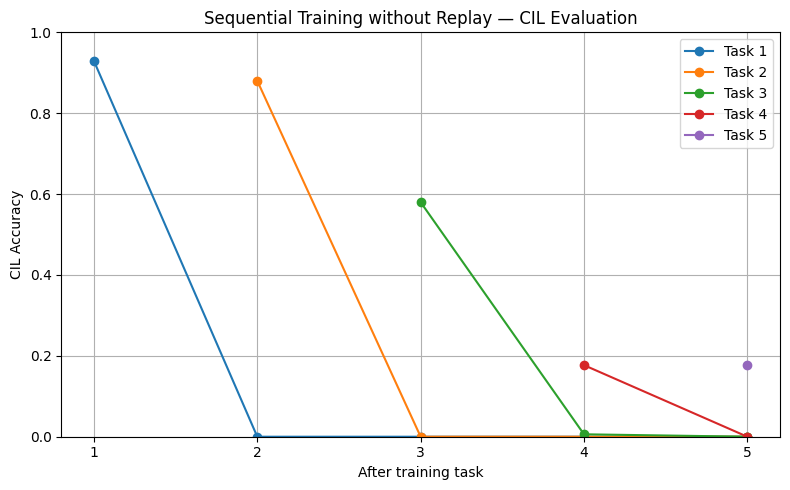

In [6]:
def run_no_replay_cil_baseline():
    set_seed(SEED)

    model = create_fresh_classifier(device=device)
    accuracy_matrix = np.full((NUM_TASKS, NUM_TASKS), np.nan)

    for task_id in range(NUM_TASKS):
        print("\n" + "=" * 60)
        print(f"Training on Task {task_id + 1}")
        print("=" * 60)

        model = train_on_task(
            model=model,
            train_dataset=train_emb_datasets[task_id],
            device=device,
            epochs=EPOCHS_PER_TASK,
            batch_size=BATCH_SIZE,
            lr=LEARNING_RATE,
            verbose=False,
        )

        seen_task_ids = list(range(task_id + 1))

        for eval_task_id in range(task_id + 1):
            acc = evaluate_on_task_seen_classes(
                model=model,
                test_dataset=test_emb_datasets[eval_task_id],
                seen_task_ids=seen_task_ids,
                task_classes=task_classes,
                class_to_local=class_to_local,
                device=device,
            )

            accuracy_matrix[task_id, eval_task_id] = acc
            print(f"Test Task {eval_task_id + 1}: acc={acc:.4f}")

    return model, accuracy_matrix


model_no_replay_cil, acc_matrix_no_replay_cil = run_no_replay_cil_baseline()

cil_acc_df = accuracy_matrix_to_dataframe(acc_matrix_no_replay_cil)
display(cil_acc_df)

forgetting_cil, avg_forgetting_cil = compute_forgetting(acc_matrix_no_replay_cil)

print("Average CIL forgetting:", avg_forgetting_cil)

save_table(
    cil_acc_df,
    tables_dir / "cil_no_replay_accuracy_matrix.csv",
    index=True,
)

plot_accuracy_matrix_over_time(
    accuracy_matrix=acc_matrix_no_replay_cil,
    num_tasks=NUM_TASKS,
    title="Sequential Training without Replay — CIL Evaluation",
    ylabel="CIL Accuracy",
    save_path=figures_dir / "cil_no_replay_accuracy.png",
)

In [7]:
# =======================================
# 5. Proactive Forgetting-Risk Estimation
# =======================================

from risk_estimator.experiments import analyze_transition_forgetting_risk

transition_t2 = analyze_transition_forgetting_risk(
    current_task_id=1,
    train_emb_datasets=train_emb_datasets,
    test_emb_datasets=test_emb_datasets,
    task_classes=task_classes,
    class_to_local=class_to_local,
    device=device,
    epochs_before=EPOCHS_PER_TASK,
    epochs_current=EPOCHS_PER_TASK,
    batch_size=BATCH_SIZE,
    lr=LEARNING_RATE,
    compute_gradient=False,
    verbose=True,
)

risk_df = transition_t2["risk_df"]
corr_df = transition_t2["corr_df"]

display(corr_df)

save_table(
    corr_df,
    tables_dir / "risk_correlation_task1_to_task2.csv",
)


######################################################################
Analyzing transition: previous tasks -> Task 2
######################################################################

Training base model on Task 1
Epoch 1/5 | loss=3.0703 | train_acc=0.3214
Epoch 2/5 | loss=1.9283 | train_acc=0.7236
Epoch 3/5 | loss=1.2936 | train_acc=0.8644
Epoch 4/5 | loss=0.7773 | train_acc=0.8762
Epoch 5/5 | loss=0.5316 | train_acc=0.8926

Computing proactive risk scores...

Training on Task 2 without replay...
Epoch 1/5 | loss=5.7242 | train_acc=0.0000
Epoch 2/5 | loss=2.9260 | train_acc=0.1316
Epoch 3/5 | loss=2.1201 | train_acc=0.7282
Epoch 4/5 | loss=1.5995 | train_acc=0.8162
Epoch 5/5 | loss=1.1244 | train_acc=0.8804

Computing actual forgetting...


,score,n,pearson_r,pearson_p,spearman_r,spearman_p
0,risk_margin,5000,0.631918,0.000000e+00,0.716087,0.000000e+00
3,combined_risk,5000,0.638615,0.000000e+00,0.646396,0.000000e+00
1,risk_probe_logit_drift,5000,0.602012,0.000000e+00,0.547133,0.000000e+00
4,corrected_probe_risk,5000,0.507086,0.000000e+00,0.509401,0.000000e+00
2,risk_probe_prob_drift,5000,0.360053,6.394158e-153,0.362402,4.840094e-155


The corrected probe risk excludes confidence-margin risk, because margin risk behaved unreliably in the CIL setting. The main risk signal is probe probability drift: a small temporary update on the incoming task is used as a stress test for old samples.

In [9]:
# ==================================================
# 6–7. Replay Memory Construction and CIL Evaluation
# ==================================================

from risk_estimator.experiments import run_replay_comparison_for_two_tasks

replay_results_df, replay_models, replay_memories = run_replay_comparison_for_two_tasks(
    model_before_task_b=transition_t2["model_before"],
    current_dataset=train_emb_datasets[1],
    risk_df=risk_df,
    base_old_dataset=train_emb_datasets[0],
    test_emb_datasets=test_emb_datasets,
    task_classes=task_classes,
    class_to_local=class_to_local,
    device=device,
    task_a=0,
    task_b=1,
    memory_size=MEMORY_SIZE,
    risk_col="corrected_probe_risk",
    epochs=EPOCHS_PER_TASK,
    batch_size=BATCH_SIZE,
    lr=LEARNING_RATE,
    verbose=True,
)

replay_results_sorted = replay_results_df.sort_values(
    "avg_acc_cil",
    ascending=False,
)

display(replay_results_sorted)

save_table(
    replay_results_sorted,
    tables_dir / "cil_replay_comparison.csv",
)

Selecting diverse samples:   0%|          | 0/499 [00:00<?, ?it/s]

Epoch 1/5 | loss=5.7211 | train_acc=0.0000
Epoch 2/5 | loss=2.9409 | train_acc=0.1266
Epoch 3/5 | loss=2.1303 | train_acc=0.7458
Epoch 4/5 | loss=1.6011 | train_acc=0.8212
Epoch 5/5 | loss=1.1261 | train_acc=0.8700

Random replay
Epoch 1/5 | loss=5.0468 | train_acc=0.0836
Epoch 2/5 | loss=2.6549 | train_acc=0.2638
Epoch 3/5 | loss=1.9836 | train_acc=0.7429
Epoch 4/5 | loss=1.4823 | train_acc=0.8011
Epoch 5/5 | loss=1.0680 | train_acc=0.8320

Corrected-probe replay
Epoch 1/5 | loss=5.0818 | train_acc=0.0785
Epoch 2/5 | loss=2.6909 | train_acc=0.2595
Epoch 3/5 | loss=2.0256 | train_acc=0.6840
Epoch 4/5 | loss=1.5275 | train_acc=0.7605
Epoch 5/5 | loss=1.1158 | train_acc=0.8105

Class-balanced corrected-probe replay
Epoch 1/5 | loss=5.1208 | train_acc=0.0755
Epoch 2/5 | loss=2.7261 | train_acc=0.2238
Epoch 3/5 | loss=2.0692 | train_acc=0.7076
Epoch 4/5 | loss=1.5802 | train_acc=0.7607
Epoch 5/5 | loss=1.1603 | train_acc=0.8120

Embedding-diverse corrected-probe replay
Epoch 1/5 | loss=5.0

,method,task1_acc_after_task2_cil,task2_acc_after_task2_cil,avg_acc_cil,task1_acc_before_task2_cil,task1_forgetting_cil
1,Random replay,0.283,0.901,0.5920,0.929,0.646
3,Class-balanced corrected-probe replay,0.265,0.904,0.5845,0.929,0.664
5,Hybrid corrected-probe 25% risk,0.255,0.899,0.5770,0.929,0.674
6,Hybrid corrected-probe 50% risk,0.232,0.902,0.5670,0.929,0.697
4,Embedding-diverse corrected-probe replay,0.158,0.897,0.5275,0.929,0.771
7,Hybrid corrected-probe 75% risk,0.150,0.899,0.5245,0.929,0.779
2,Corrected-probe replay,0.093,0.885,0.4890,0.929,0.836
0,No replay,0.000,0.879,0.4395,0.929,0.929


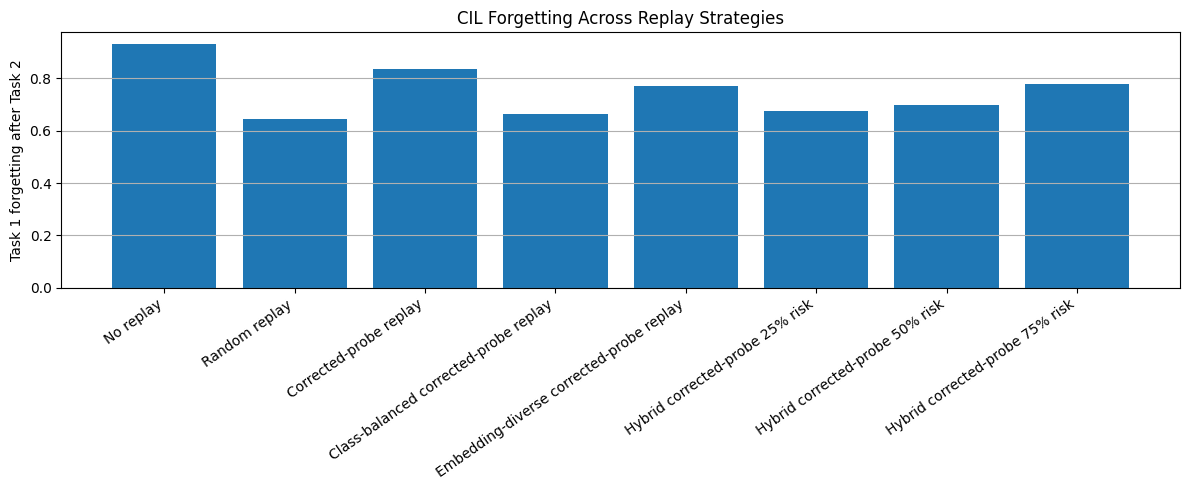

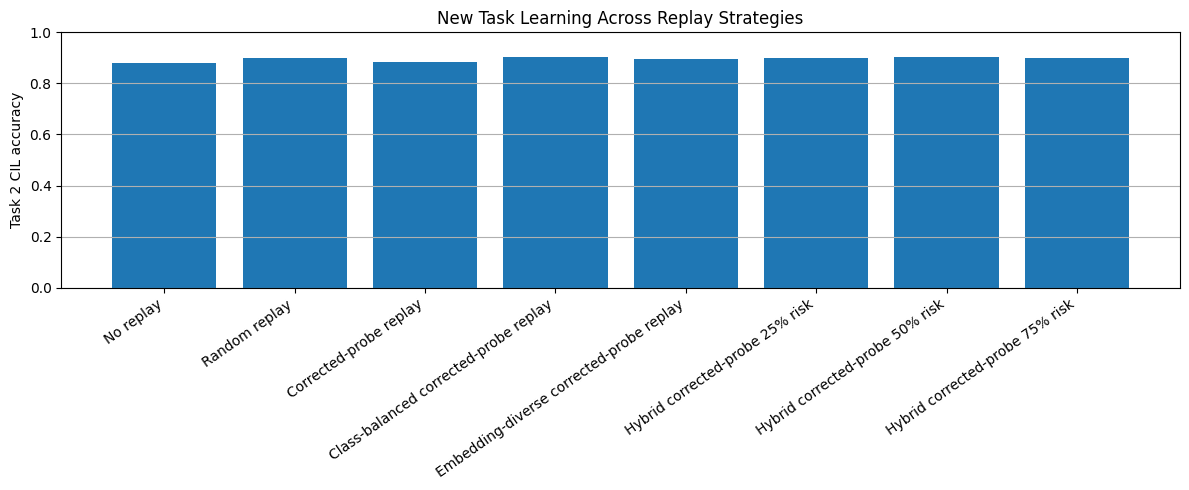

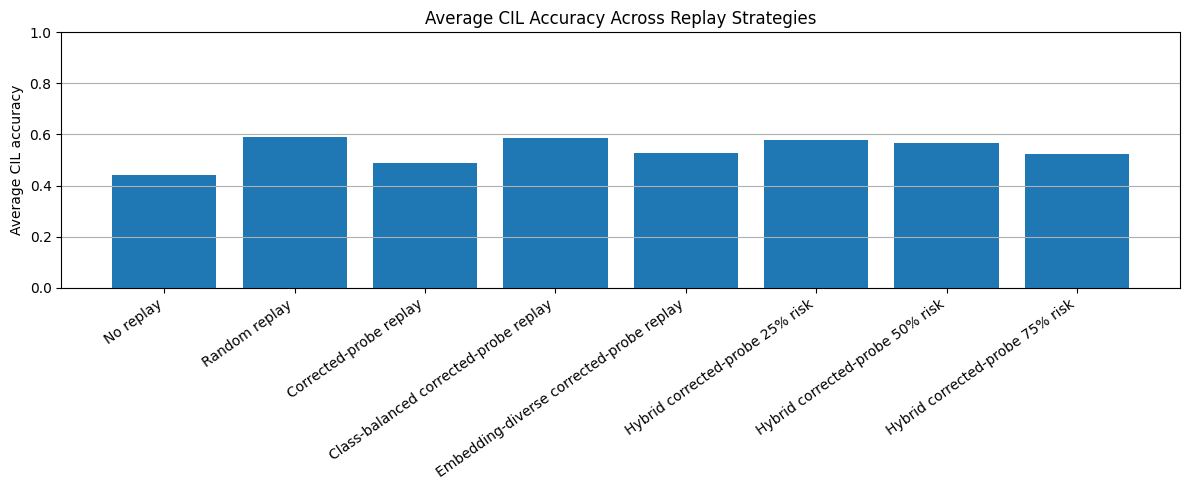

In [10]:
plot_bar_metric(
    df=replay_results_df,
    x_col="method",
    y_col="task1_forgetting_cil",
    title="CIL Forgetting Across Replay Strategies",
    ylabel="Task 1 forgetting after Task 2",
    save_path=figures_dir / "cil_forgetting_replay_strategies.png",
)

plot_bar_metric(
    df=replay_results_df,
    x_col="method",
    y_col="task2_acc_after_task2_cil",
    title="New Task Learning Across Replay Strategies",
    ylabel="Task 2 CIL accuracy",
    ylim=(0, 1),
    save_path=figures_dir / "cil_task2_accuracy_replay_strategies.png",
)

plot_bar_metric(
    df=replay_results_df,
    x_col="method",
    y_col="avg_acc_cil",
    title="Average CIL Accuracy Across Replay Strategies",
    ylabel="Average CIL accuracy",
    ylim=(0, 1),
    save_path=figures_dir / "cil_avg_accuracy_replay_strategies.png",
)

,original_label,count,class_name
0,0,48,apple
1,1,54,aquarium_fish
2,2,55,baby
3,3,43,bear
4,4,53,beaver
5,5,48,bed
6,6,44,bee
7,7,54,beetle
8,8,53,bicycle
9,9,48,bottle


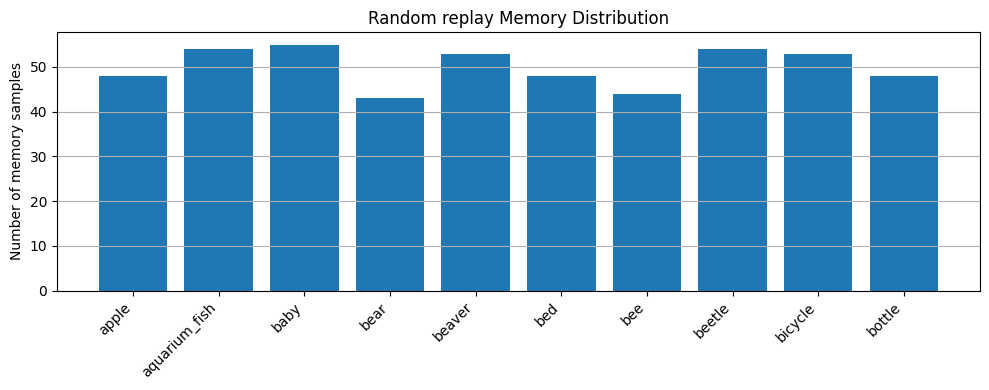

,original_label,count,class_name
0,0,5,apple
1,1,14,aquarium_fish
2,2,215,baby
3,3,69,bear
4,4,12,beaver
5,5,28,bed
6,6,42,bee
7,7,43,beetle
8,8,10,bicycle
9,9,62,bottle


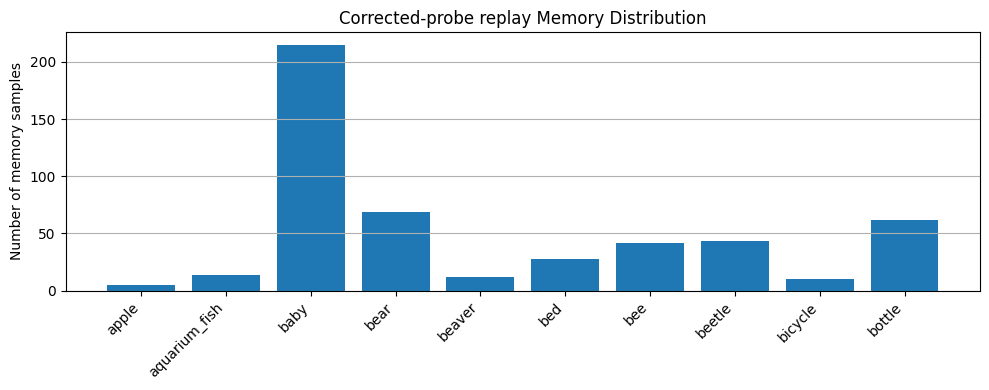

,original_label,count,class_name
0,0,50,apple
1,1,50,aquarium_fish
2,2,50,baby
3,3,50,bear
4,4,50,beaver
5,5,50,bed
6,6,50,bee
7,7,50,beetle
8,8,50,bicycle
9,9,50,bottle


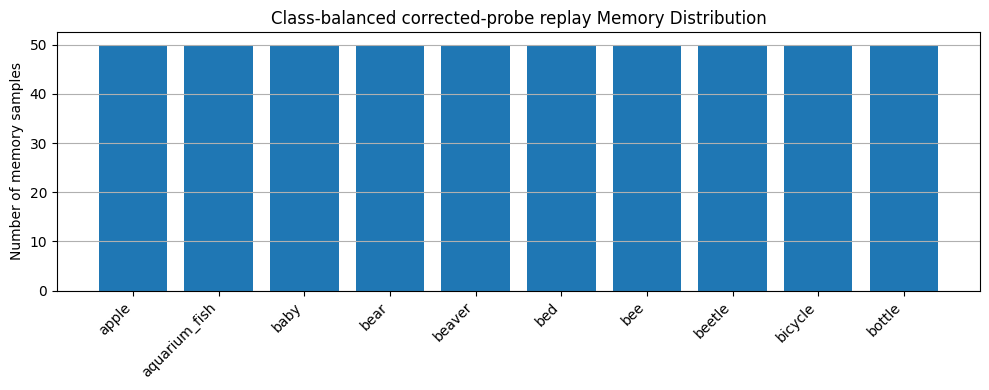

,original_label,count,class_name
0,0,14,apple
1,1,23,aquarium_fish
2,2,130,baby
3,3,51,bear
4,4,36,beaver
5,5,30,bed
6,6,31,bee
7,7,64,beetle
8,8,36,bicycle
9,9,85,bottle


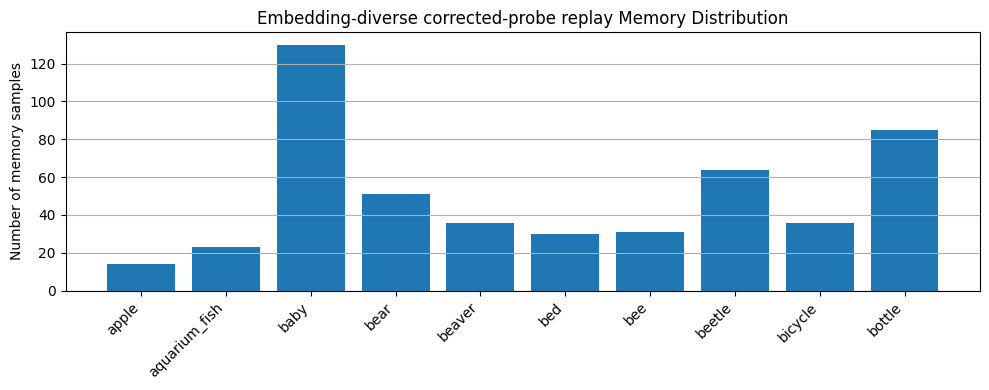

,original_label,count,class_name
0,0,38,apple
1,1,47,aquarium_fish
2,2,124,baby
3,3,36,bear
4,4,46,beaver
5,5,47,bed
6,6,32,bee
7,7,25,beetle
8,8,50,bicycle
9,9,55,bottle


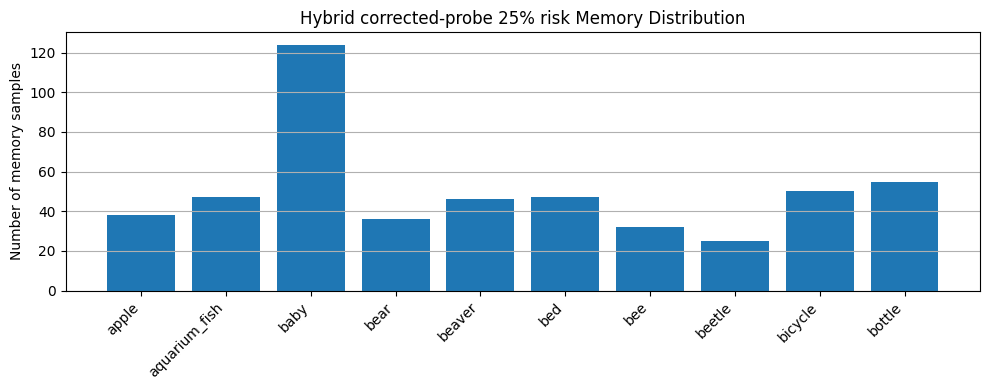

,original_label,count,class_name
0,0,34,apple
1,1,27,aquarium_fish
2,2,170,baby
3,3,50,bear
4,4,32,beaver
5,5,36,bed
6,6,29,bee
7,7,30,beetle
8,8,37,bicycle
9,9,55,bottle


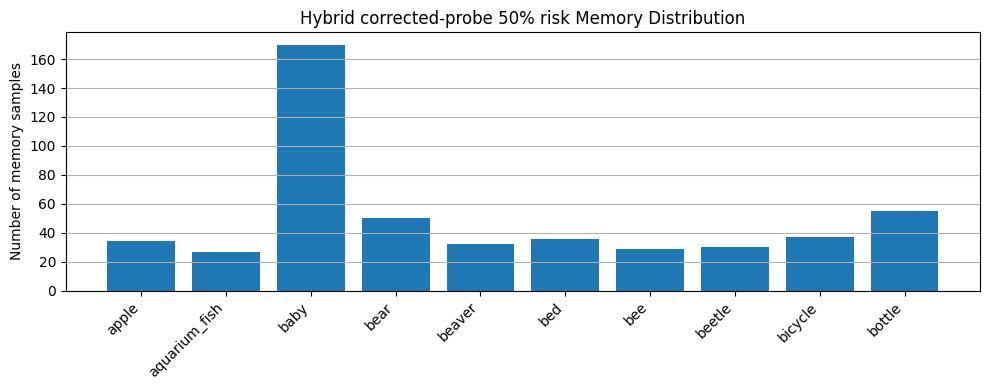

,original_label,count,class_name
0,0,16,apple
1,1,24,aquarium_fish
2,2,196,baby
3,3,62,bear
4,4,21,beaver
5,5,32,bed
6,6,41,bee
7,7,33,beetle
8,8,18,bicycle
9,9,57,bottle


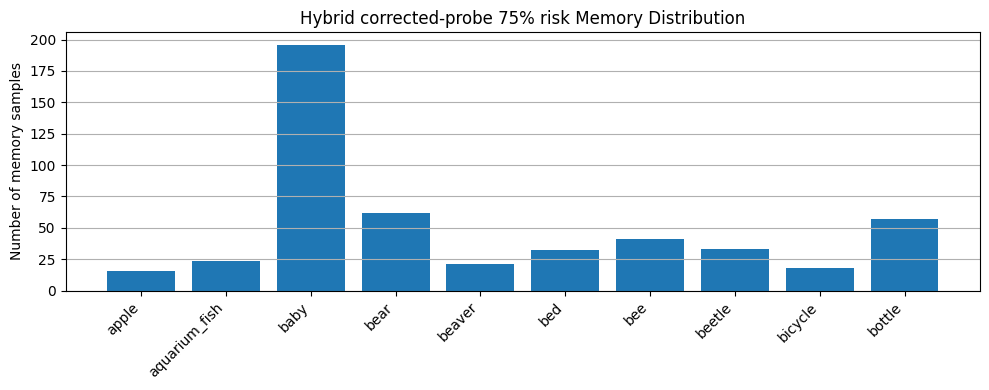

In [11]:
# ===============================
# 8. Memory Distribution Analysis
# ===============================

from risk_estimator.memory import memory_class_distribution

for method_name, memory_dataset in replay_memories.items():
    dist_df = memory_class_distribution(
        memory_dataset,
        class_names=class_names,
    )

    display(dist_df)

    safe_name = (
        method_name.lower()
        .replace(" ", "_")
        .replace("+", "plus")
        .replace("%", "pct")
    )

    save_table(
        dist_df,
        tables_dir / f"memory_distribution_{safe_name}.csv",
    )

    plot_memory_distribution(
        dist_df,
        title=f"{method_name} Memory Distribution",
        save_path=figures_dir / f"memory_distribution_{safe_name}.png",
    )

In [13]:
# =================================================
# 10. Transition Analysis: Task 1 + Task 2 → Task 3
# =================================================

from risk_estimator.evaluation import summarize_temporal_forgetting

transition_t3 = analyze_transition_forgetting_risk(
    current_task_id=2,
    train_emb_datasets=train_emb_datasets,
    test_emb_datasets=test_emb_datasets,
    task_classes=task_classes,
    class_to_local=class_to_local,
    device=device,
    epochs_before=EPOCHS_PER_TASK,
    epochs_current=EPOCHS_PER_TASK,
    batch_size=BATCH_SIZE,
    lr=LEARNING_RATE,
    compute_gradient=False,
    verbose=True,
)

display(transition_t3["corr_df"])

save_table(
    transition_t3["corr_df"],
    tables_dir / "risk_correlation_task12_to_task3.csv",
)

temporal_t3 = summarize_temporal_forgetting(
    transition_t3["eval_df"]
)

display(temporal_t3)

save_table(
    temporal_t3,
    tables_dir / "temporal_forgetting_task12_to_task3.csv",
)


######################################################################
Analyzing transition: previous tasks -> Task 3
######################################################################

Training base model on Task 1
Epoch 1/5 | loss=3.0703 | train_acc=0.3214
Epoch 2/5 | loss=1.9283 | train_acc=0.7236
Epoch 3/5 | loss=1.2936 | train_acc=0.8644
Epoch 4/5 | loss=0.7773 | train_acc=0.8762
Epoch 5/5 | loss=0.5316 | train_acc=0.8926

Training base model on Task 2
Epoch 1/5 | loss=5.7134 | train_acc=0.0000
Epoch 2/5 | loss=2.9295 | train_acc=0.1406
Epoch 3/5 | loss=2.1188 | train_acc=0.7040
Epoch 4/5 | loss=1.5923 | train_acc=0.8156
Epoch 5/5 | loss=1.1226 | train_acc=0.8594

Computing proactive risk scores...

Training on Task 3 without replay...
Epoch 1/5 | loss=7.9757 | train_acc=0.0000
Epoch 2/5 | loss=4.2269 | train_acc=0.0000
Epoch 3/5 | loss=3.2039 | train_acc=0.0648
Epoch 4/5 | loss=2.5847 | train_acc=0.4174
Epoch 5/5 | loss=2.1535 | train_acc=0.5412

Computing actual forgetting.

,score,n,pearson_r,pearson_p,spearman_r,spearman_p
1,risk_probe_logit_drift,10000,0.134512,1.347634e-41,0.190589,1.955405e-82
4,corrected_probe_risk,10000,0.140633,2.417270e-45,0.141433,7.606193e-46
2,risk_probe_prob_drift,10000,0.095361,1.215996e-21,0.084498,2.585145e-17
3,combined_risk,10000,-0.395601,0.000000e+00,-0.407480,0.000000e+00
0,risk_margin,10000,-0.618415,0.000000e+00,-0.628970,0.000000e+00


,task_id,avg_loss_increase,avg_prob_drop,forgotten_rate,avg_combined_risk,n,task_name
0,0,1.976858,0.031631,0.9996,0.467390,5000,Task 1
1,1,2.815956,0.403100,1.0000,0.315769,5000,Task 2


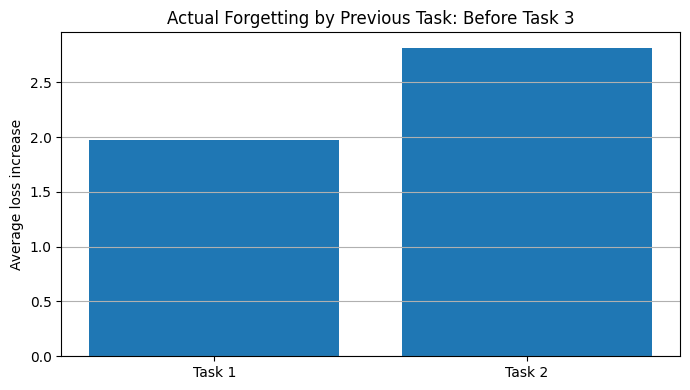

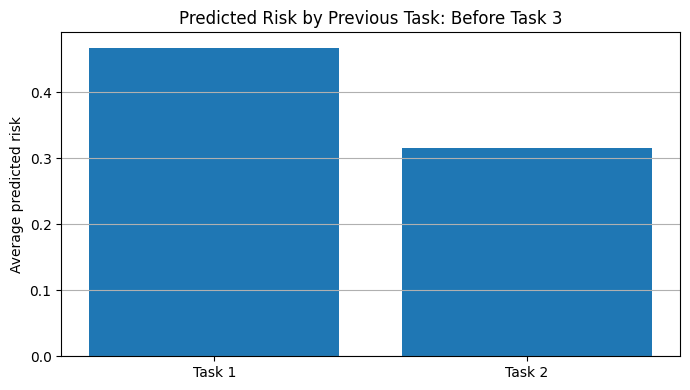

In [14]:
plot_temporal_summary(
    temporal_t3,
    y_col="avg_loss_increase",
    title="Actual Forgetting by Previous Task: Before Task 3",
    ylabel="Average loss increase",
    save_path=figures_dir / "temporal_actual_forgetting_task3.png",
)

plot_temporal_summary(
    temporal_t3,
    y_col="avg_combined_risk",
    title="Predicted Risk by Previous Task: Before Task 3",
    ylabel="Average predicted risk",
    save_path=figures_dir / "temporal_predicted_risk_task3.png",
)